You can find the lecture [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/lectures/L06_frequentist.ipynb)

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

In [2]:
data=np.load('/Users/simoneabeni/Desktop/GitHub/reps/astrostatistics_bicocca_2026/solutions/formationchannels.npy')

Histogramming the data

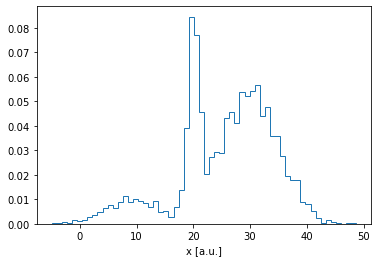

In [7]:
plt.hist(data,histtype='step',bins=60,density=True);
plt.xlabel('x [a.u.]')
plt.show()

In [34]:
#compute aic
N=10
aic = np.empty(N)
for i in np.arange(1,N+1):
    aic[i-1] = GaussianMixture(i).fit(data).aic(data)
np.min(aic)
#-----------------------
#index of the minimum +1, input to GaussianMixture(k).fit(data)
k=int(np.argwhere(aic == np.min(aic)).flatten()[0]) + 1

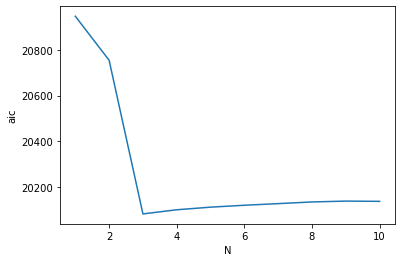

In [4]:
#aic vs. N
plt.plot(np.arange(1,N+1),aic);
plt.xlabel('N')
plt.ylabel('aic')
plt.show()

Plot of the Gaussian functions and their mixture

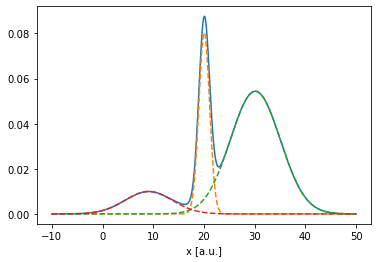

In [35]:
xgrid = np.linspace(-10,50,10**5)
gm3 = GaussianMixture(k).fit(data) #GM fit with 'k' computed above
gm3_means=gm3.means_.flatten() #array of means
gm3_dev=((gm3.covariances_)**0.5).flatten() #array of sigmas
gm3_weights=gm3.weights_.flatten() #array of weights
y = np.array([w*norm.pdf(xgrid,loc=x_0,scale=s) for (w,x_0,s) in zip(gm3_weights,gm3_means,gm3_dev)])
Y=np.sum(y,axis=0,keepdims=True).flatten()
fig, ax = plt.subplots()
#for yi in Y:
plt.plot(xgrid,Y,ls='-')
for yi in y:
    plt.plot(xgrid,yi,ls='--')
plt.xlabel('x [a.u.]')
plt.show()

Plot of the Gaussian mixture and the normalized histogram

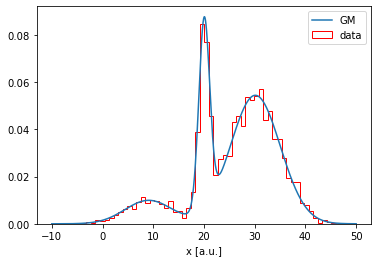

In [36]:
fig, ax = plt.subplots()
plt.plot(xgrid,Y,ls='-',label='GM')
plt.hist(data,histtype='step',bins=60,density=True,color='red',label='data');
plt.xlabel('x [a.u.]')
plt.legend()
plt.show()